<h1 style=" text-align:center; color:Blue; font-size:40px;"> <u><b>Heart Attack Prediction With 91.8% Accuracy</b></u> </h1>

<p style="text-align:center; ">
<img src="https://media.giphy.com/media/8cBhJBU2wlq6H6qY4W/giphy.gif">
</p>



# **<p style="color:Blue;">About The Dataset :</p>**
    
age: Age of the patient

sex: Sex of the patient

cp: Chest pain type, 0 = Typical Angina, 1 = Atypical Angina, 2 = Non-anginal Pain, 3 = Asymptomatic

trtbps: Resting blood pressure (in mm Hg)

chol: Cholestoral in mg/dl fetched via BMI sensor

fbs: (fasting blood sugar > 120 mg/dl), 1 = True, 0 = False

restecg: Resting electrocardiographic results, 0 = Normal, 1 = ST-T wave normality, 2 = Left ventricular hypertrophy

thalachh: Maximum heart rate achieved

oldpeak: Previous peak

slp: Slope

caa: Number of major vessels

thall: Thalium Stress Test result ~ (0,3)

exng: Exercise induced angina ~ 1 = Yes, 0 = No

output: Target variable



In [1]:
import seaborn as sns
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler 
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier  
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import BernoulliNB
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)



import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


***Reading The Dataset***

In [3]:
heart=pd.read_csv('heart.csv')
print(heart.shape)
heart.head()

(303, 14)


,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


***Checking the shape of DataFrame***

In [4]:
print('Number of rows are',heart.shape[0], 'and number of columns are ',heart.shape[1])

Number of rows are 303 and number of columns are  14


***Checking for null values***

In [5]:
heart.isnull().sum()/len(heart)*100

age         0.0
sex         0.0
cp          0.0
trtbps      0.0
chol        0.0
fbs         0.0
restecg     0.0
thalachh    0.0
exng        0.0
oldpeak     0.0
slp         0.0
caa         0.0
thall       0.0
output      0.0
dtype: float64

**No null values found**

***Checking For datatypes of the attributes***

In [6]:
heart.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trtbps    303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalachh  303 non-null    int64  
 8   exng      303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slp       303 non-null    int64  
 11  caa       303 non-null    int64  
 12  thall     303 non-null    int64  
 13  output    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


**All attributes are of type 'int' except 'oldpeak'**

***Checking for duplicate rows***

In [7]:
heart[heart.duplicated()]


,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
164,38,1,2,138,175,0,1,173,0,0.0,2,4,2,1


***Removing the duplicates***

In [8]:
heart.drop_duplicates(keep='first',inplace=True)


**Checking new shape**

In [9]:
print('Number of rows are',heart.shape[0], 'and number of columns are ',heart.shape[1])

Number of rows are 302 and number of columns are  14


***Checking statistical data***

In [10]:
heart.describe()

,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
count,302.00000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000
mean,54.42053,0.682119,0.963576,131.602649,246.500000,0.149007,0.526490,149.569536,0.327815,1.043046,1.397351,0.718543,2.314570,0.543046
std,9.04797,0.466426,1.032044,17.563394,51.753489,0.356686,0.526027,22.903527,0.470196,1.161452,0.616274,1.006748,0.613026,0.498970
min,29.00000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.00000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.250000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.50000,1.000000,1.000000,130.000000,240.500000,0.000000,1.000000,152.500000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.00000,1.000000,2.000000,140.000000,274.750000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.00000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


***Computing the correlation matrix***

In [11]:
heart.corr()

,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
age,1.000000,-0.094962,-0.063107,0.283121,0.207216,0.119492,-0.111590,-0.395235,0.093216,0.206040,-0.164124,0.302261,0.065317,-0.221476
sex,-0.094962,1.000000,-0.051740,-0.057647,-0.195571,0.046022,-0.060351,-0.046439,0.143460,0.098322,-0.032990,0.113060,0.211452,-0.283609
cp,-0.063107,-0.051740,1.000000,0.046486,-0.072682,0.096018,0.041561,0.293367,-0.392937,-0.146692,0.116854,-0.195356,-0.160370,0.432080
trtbps,0.283121,-0.057647,0.046486,1.000000,0.125256,0.178125,-0.115367,-0.048023,0.068526,0.194600,-0.122873,0.099248,0.062870,-0.146269
chol,0.207216,-0.195571,-0.072682,0.125256,1.000000,0.011428,-0.147602,-0.005308,0.064099,0.050086,0.000417,0.086878,0.096810,-0.081437
fbs,0.119492,0.046022,0.096018,0.178125,0.011428,1.000000,-0.083081,-0.007169,0.024729,0.004514,-0.058654,0.144935,-0.032752,-0.026826
restecg,-0.111590,-0.060351,0.041561,-0.115367,-0.147602,-0.083081,1.000000,0.041210,-0.068807,-0.056251,0.090402,-0.083112,-0.010473,0.134874
thalachh,-0.395235,-0.046439,0.293367,-0.048023,-0.005308,-0.007169,0.041210,1.000000,-0.377411,-0.342201,0.384754,-0.228311,-0.094910,0.419955
exng,0.093216,0.143460,-0.392937,0.068526,0.064099,0.024729,-0.068807,-0.377411,1.000000,0.286766,-0.256106,0.125377,0.205826,-0.435601
oldpeak,0.206040,0.098322,-0.146692,0.194600,0.050086,0.004514,-0.056251,-0.342201,0.286766,1.000000,-0.576314,0.236560,0.209090,-0.429146


# ***Data Visualization***

***Breakdown of gender***

Number of people having sex as 1 are 96 and Number of people having sex as 0 are 206


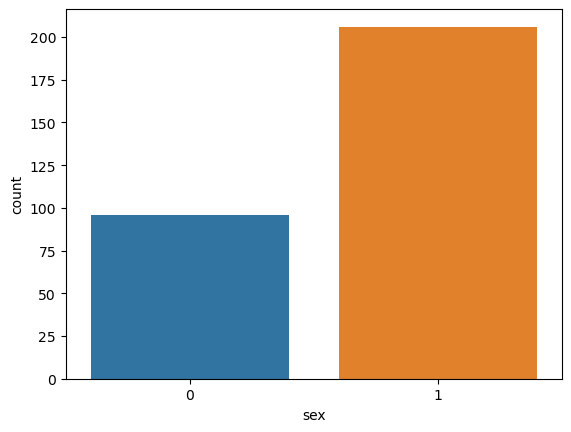

In [12]:
x=(heart.sex.value_counts())
print(f'Number of people having sex as 1 are {x[0]} and Number of people having sex as 0 are {x[1]}')
p = sns.countplot(data=heart, x="sex")
plt.show()

**People having gender as 0 are more than twice the people having gender as 1**

***Breakdown for chest pain***

cp
0    143
2     86
1     50
3     23
Name: count, dtype: int64


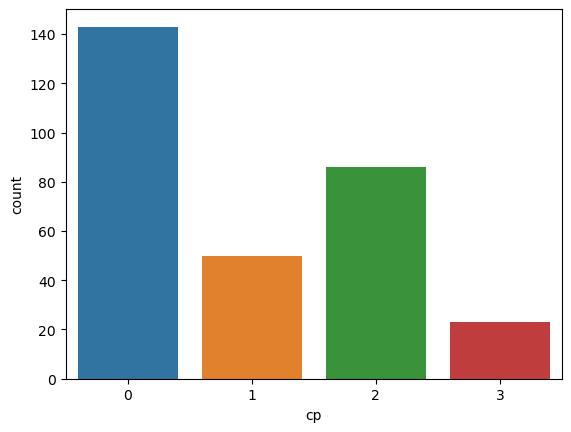

In [13]:
x=(heart.cp.value_counts())
print(x)
p = sns.countplot(data=heart, x="cp")
plt.show()

cp
0    143
2     86
1     50
3     23
Name: count, dtype: int64


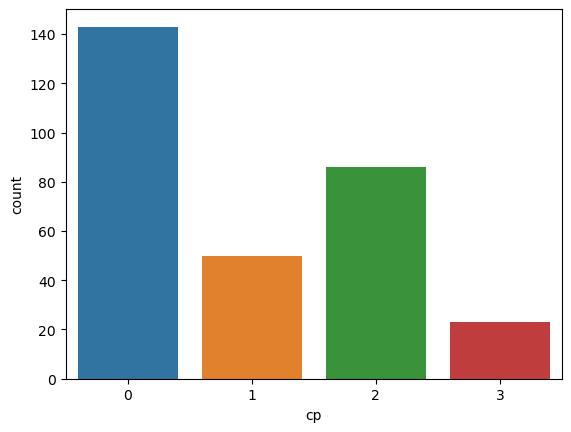

In [14]:
x=(heart.cp.value_counts())
print(x)
p = sns.countplot(data=heart, x="cp")
plt.show()

1. It can be observed people have chest pain of type 0 i.e 'Typical Angina' is the highest.
2. It can be observed people have chest pain of type 3 i.e 'Asymptomatic' is the lowest
3. It can also be observed people with chest pain of type 0 is almost 50% of all the people.

***Breakdown of FBS***

fbs
0    257
1     45
Name: count, dtype: int64


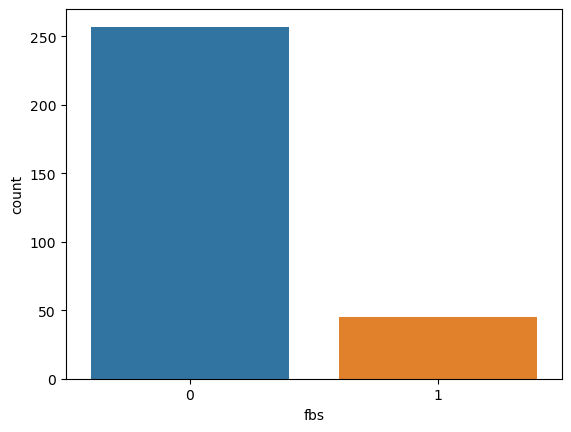

In [15]:
x=(heart.fbs.value_counts())
print(x)
p = sns.countplot(data=heart, x="fbs")
plt.show()



> FBS with value 0 is significantly higher than value 1.

***Breakdown of ECG***

restecg
1    151
0    147
2      4
Name: count, dtype: int64


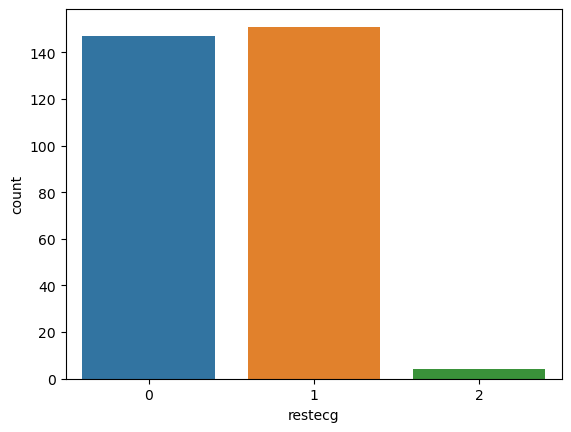

In [16]:
x=(heart.restecg.value_counts())
print(x)
p = sns.countplot(data=heart, x="restecg")
plt.show()



ECG count is almost the same for type 0 and 1. Also, for type 2 its almost negligible in comparision to type 0 and 1.

***Breakdown for Exercise Induced Angina***

exng
0    203
1     99
Name: count, dtype: int64


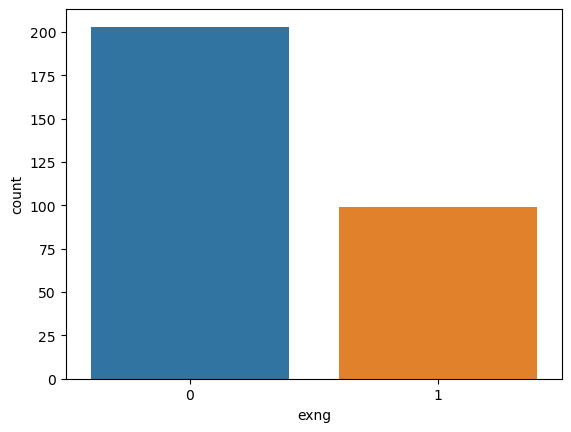

In [17]:
x=(heart.exng.value_counts())
print(x)
p = sns.countplot(data=heart, x="exng")
plt.show()


***EXNG count is more than double for type 0***

***Breakdown for Thalium Stress Test***

thall
2    165
3    117
1     18
0      2
Name: count, dtype: int64


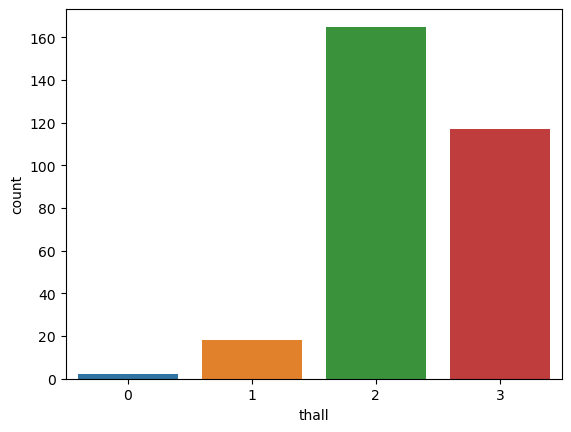

In [18]:
x=(heart.thall.value_counts())
print(x)
p = sns.countplot(data=heart, x="thall")
plt.show()


***Thall count is max for type 2 and min for type 0.***

***Density distribution for Age***

C:\Users\ASUS\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


<Figure size 1000x1000 with 0 Axes>

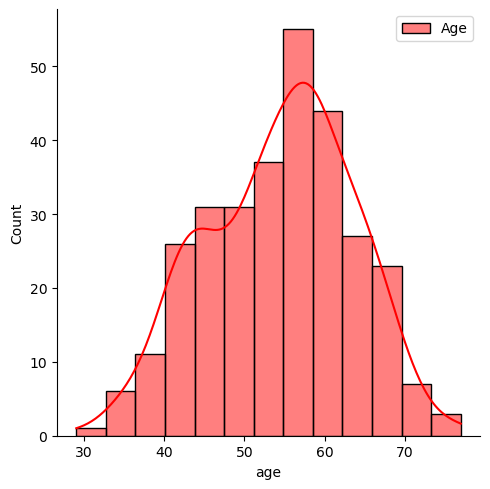

In [19]:
plt.figure(figsize=(10,10))
sns.displot(heart.age, color="red", label="Age", kde= True)
plt.legend()

**Density distribution is highest for age group 55 to 60**


C:\Users\ASUS\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


<Figure size 2000x2000 with 0 Axes>

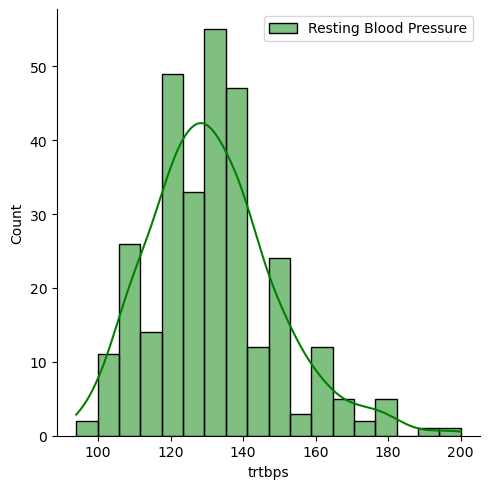

In [20]:
plt.figure(figsize=(20,20))
sns.displot(heart.trtbps , color="green", label="Resting Blood Pressure", kde= True)
plt.legend()

***Trtbs has the highest count around 130***

***Heart Attack Vs Age***

C:\Users\ASUS\AppData\Local\Temp\ipykernel_2792\2570003738.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(heart[heart['output'] == 0]["age"], color='green',kde=True,)
C:\Users\ASUS\AppData\Local\Temp\ipykernel_2792\2570003738.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(heart[heart['

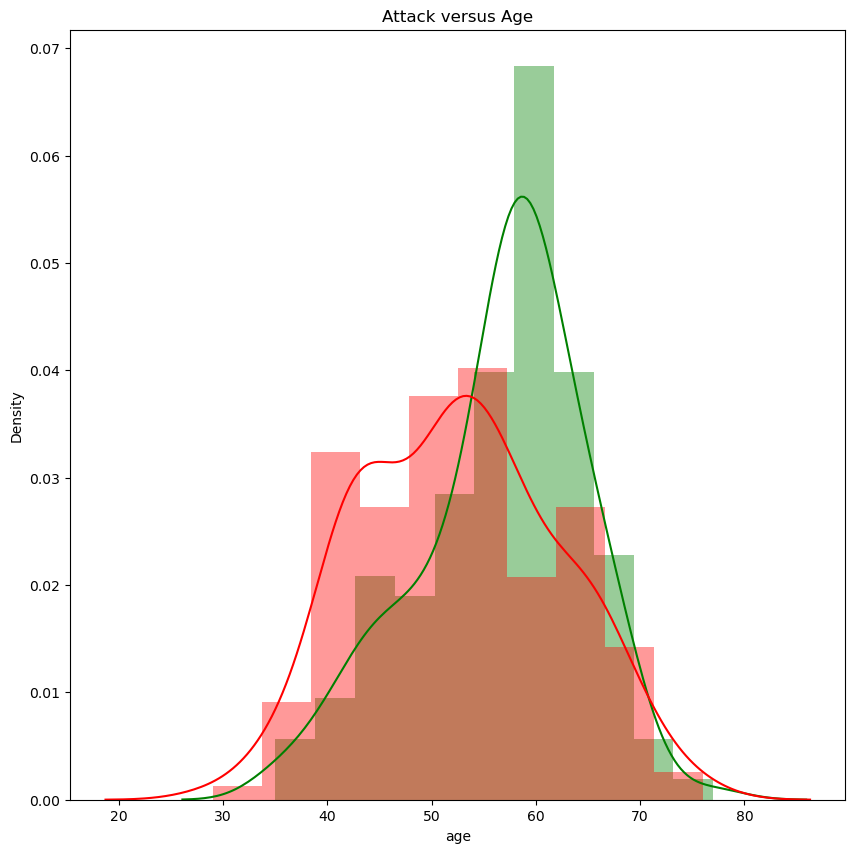

In [21]:
plt.figure(figsize=(10,10))
sns.distplot(heart[heart['output'] == 0]["age"], color='green',kde=True,) 
sns.distplot(heart[heart['output'] == 1]["age"], color='red',kde=True)
plt.title('Attack versus Age')
plt.show()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_2792\1308190982.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(heart[heart['output'] == 0]["chol"], color='green',kde=True,)
C:\Users\ASUS\AppData\Local\Temp\ipykernel_2792\1308190982.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(heart[heart[

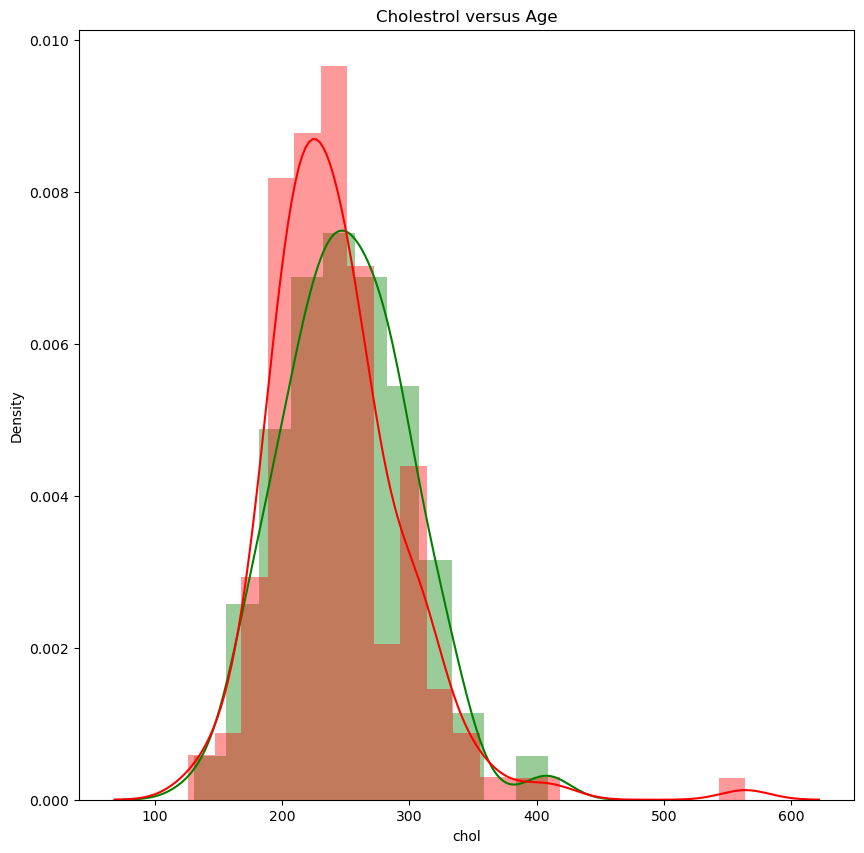

In [22]:
plt.figure(figsize=(10,10))
sns.distplot(heart[heart['output'] == 0]["chol"], color='green',kde=True,) 
sns.distplot(heart[heart['output'] == 1]["chol"], color='red',kde=True)
plt.title('Cholestrol versus Age')
plt.show()


C:\Users\ASUS\AppData\Local\Temp\ipykernel_2792\660625130.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(heart[heart['output'] == 0]["trtbps"], color='green',kde=True,)
C:\Users\ASUS\AppData\Local\Temp\ipykernel_2792\660625130.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(heart[heart[

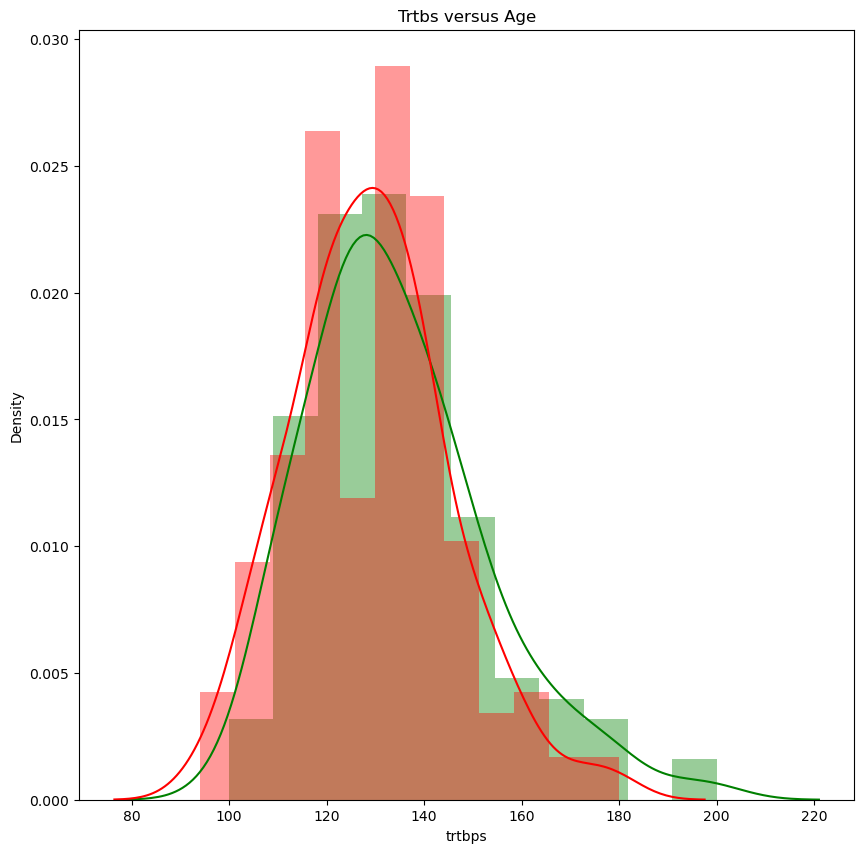

In [23]:
plt.figure(figsize=(10,10))
sns.distplot(heart[heart['output'] == 0]["trtbps"], color='green',kde=True,) 
sns.distplot(heart[heart['output'] == 1]["trtbps"], color='red',kde=True)
plt.title('Trtbs versus Age')
plt.show()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_2792\2370117659.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(heart[heart['output'] == 0]["thalachh"], color='green',kde=True,)
C:\Users\ASUS\AppData\Local\Temp\ipykernel_2792\2370117659.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(heart[he

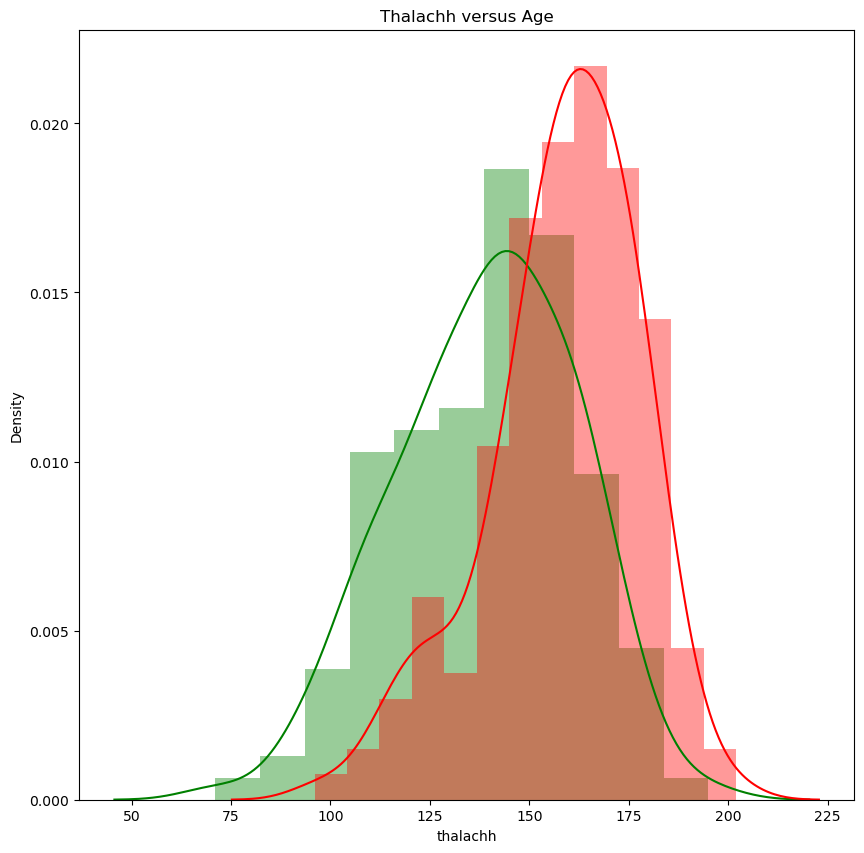

In [24]:
plt.figure(figsize=(10,10))
sns.distplot(heart[heart['output'] == 0]["thalachh"], color='green',kde=True,) 
sns.distplot(heart[heart['output'] == 1]["thalachh"], color='red',kde=True)
plt.title('Thalachh versus Age')
plt.show()


***Pair Plot***

C:\Users\ASUS\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


<Figure size 2000x2000 with 0 Axes>

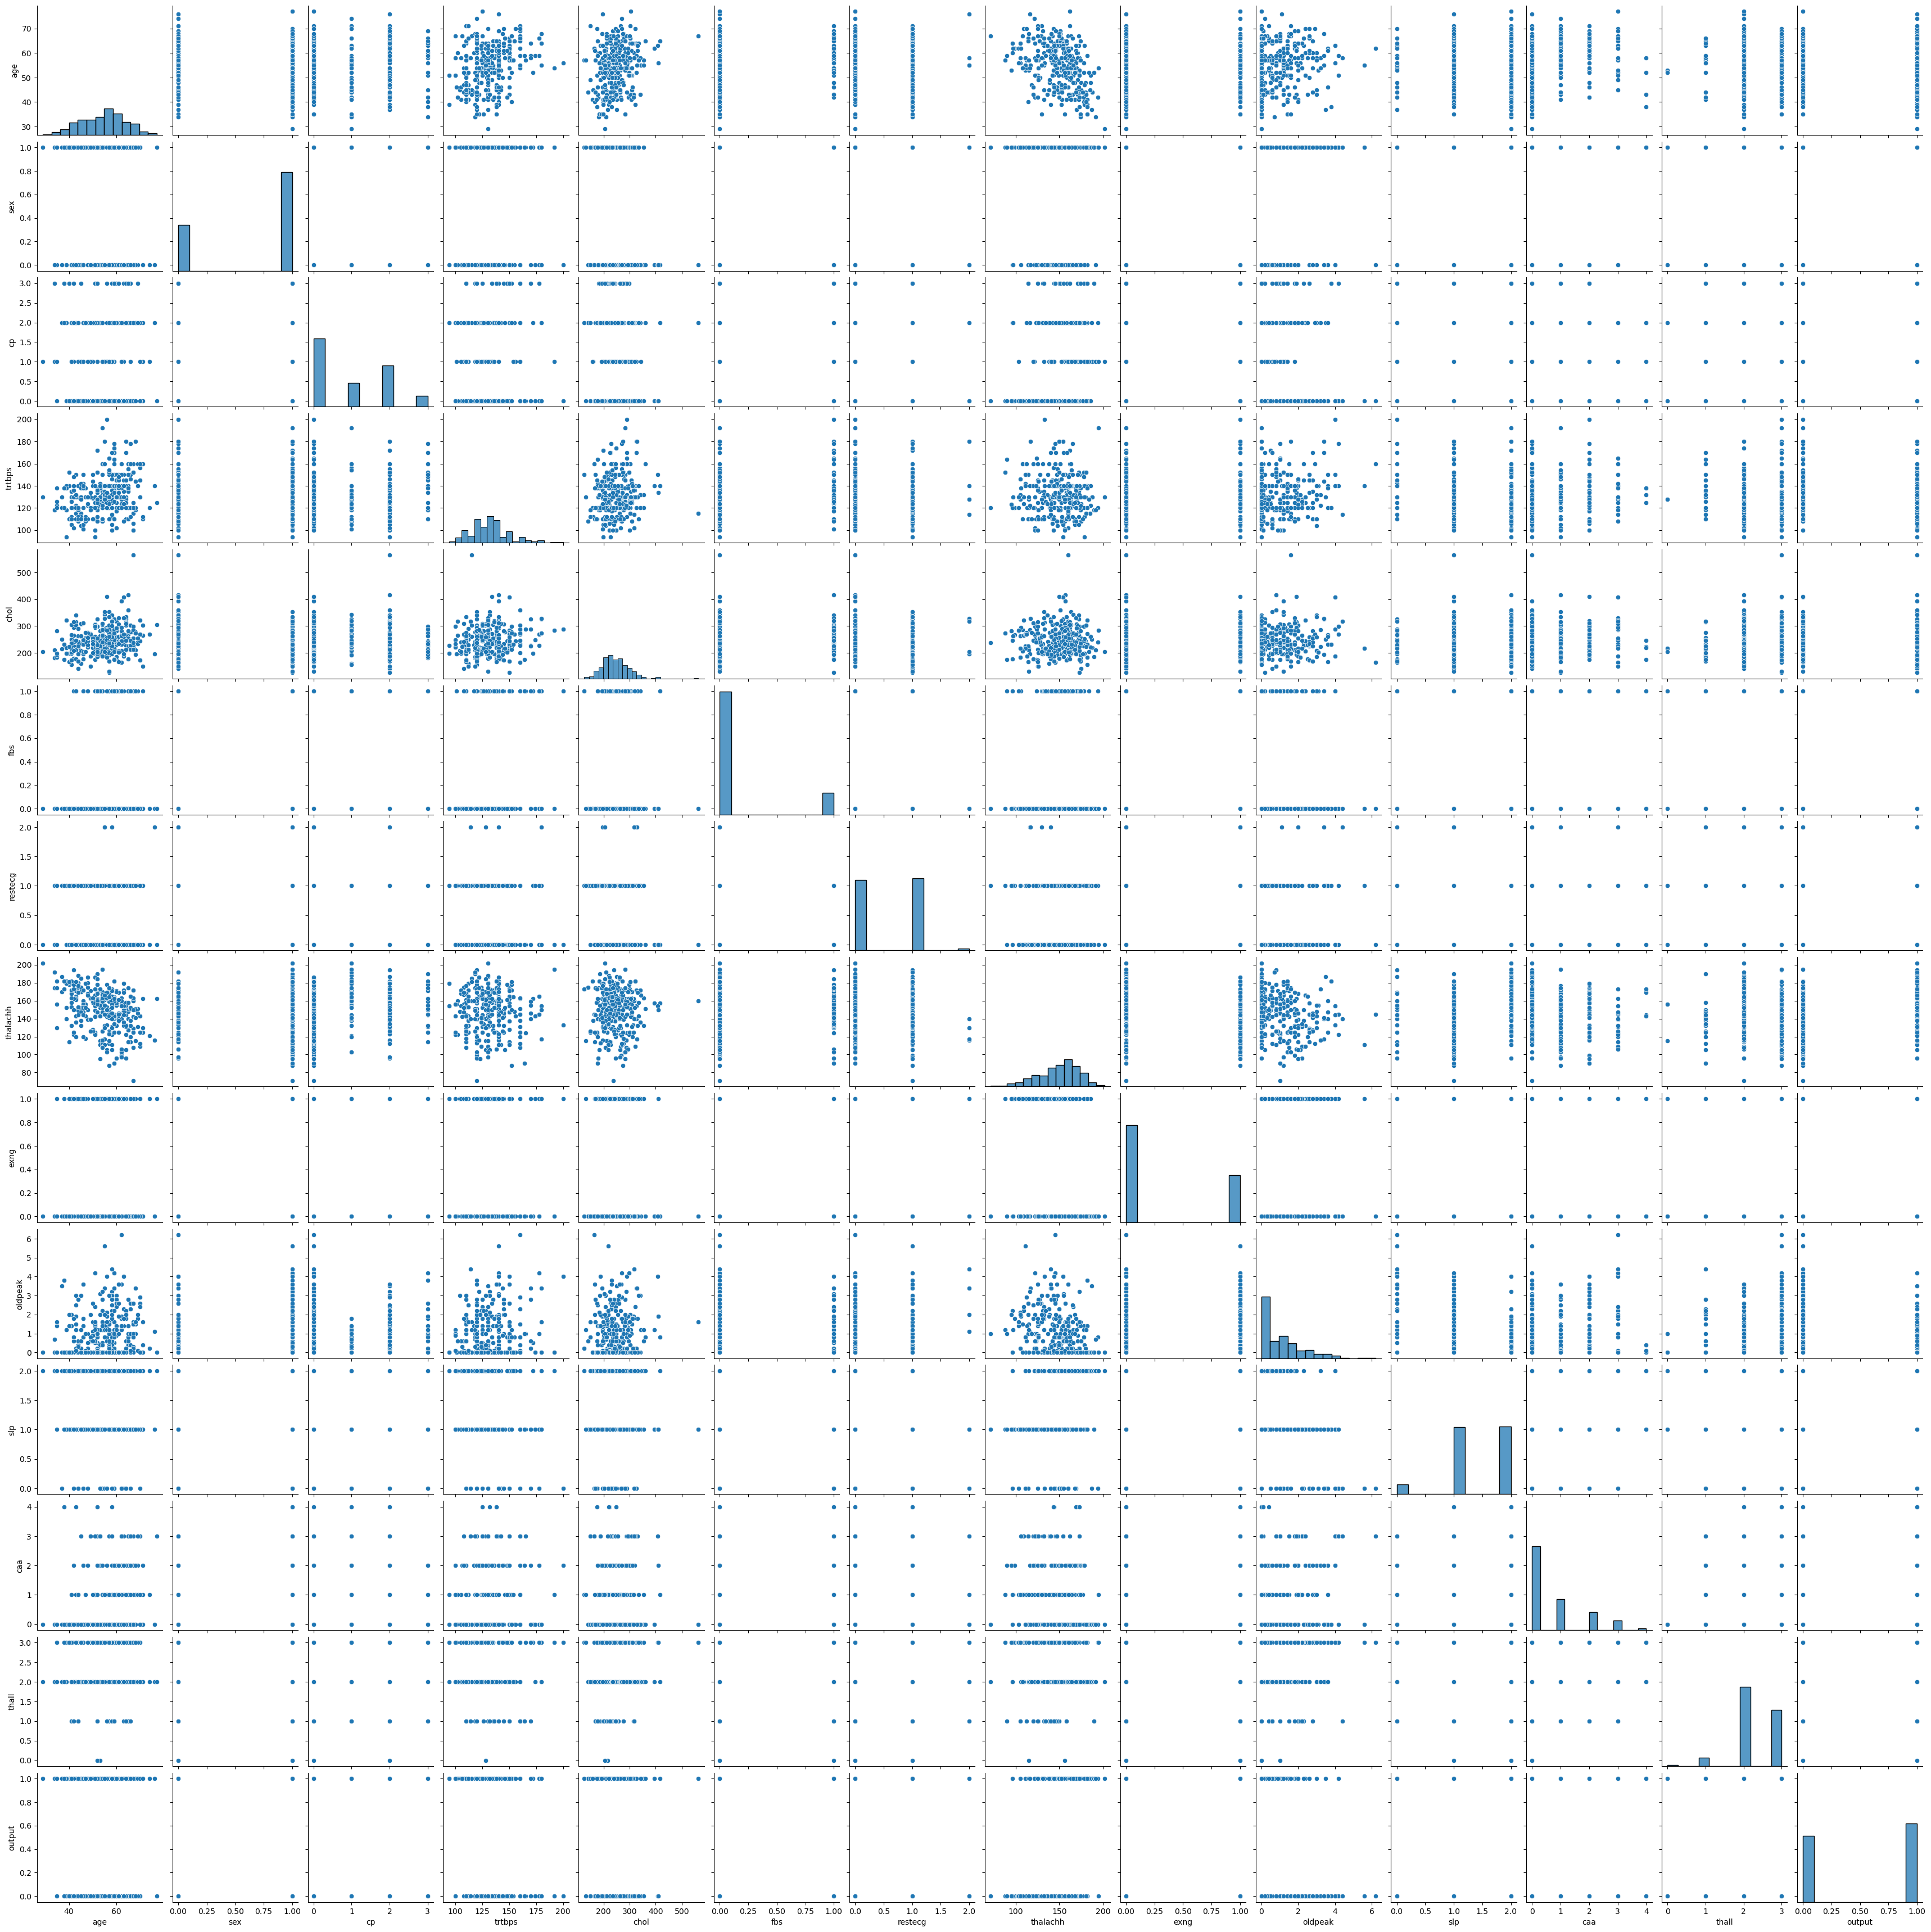

In [25]:
plt.figure(figsize=(20,20))
sns.pairplot(heart)
plt.show()

***Violin Plot***

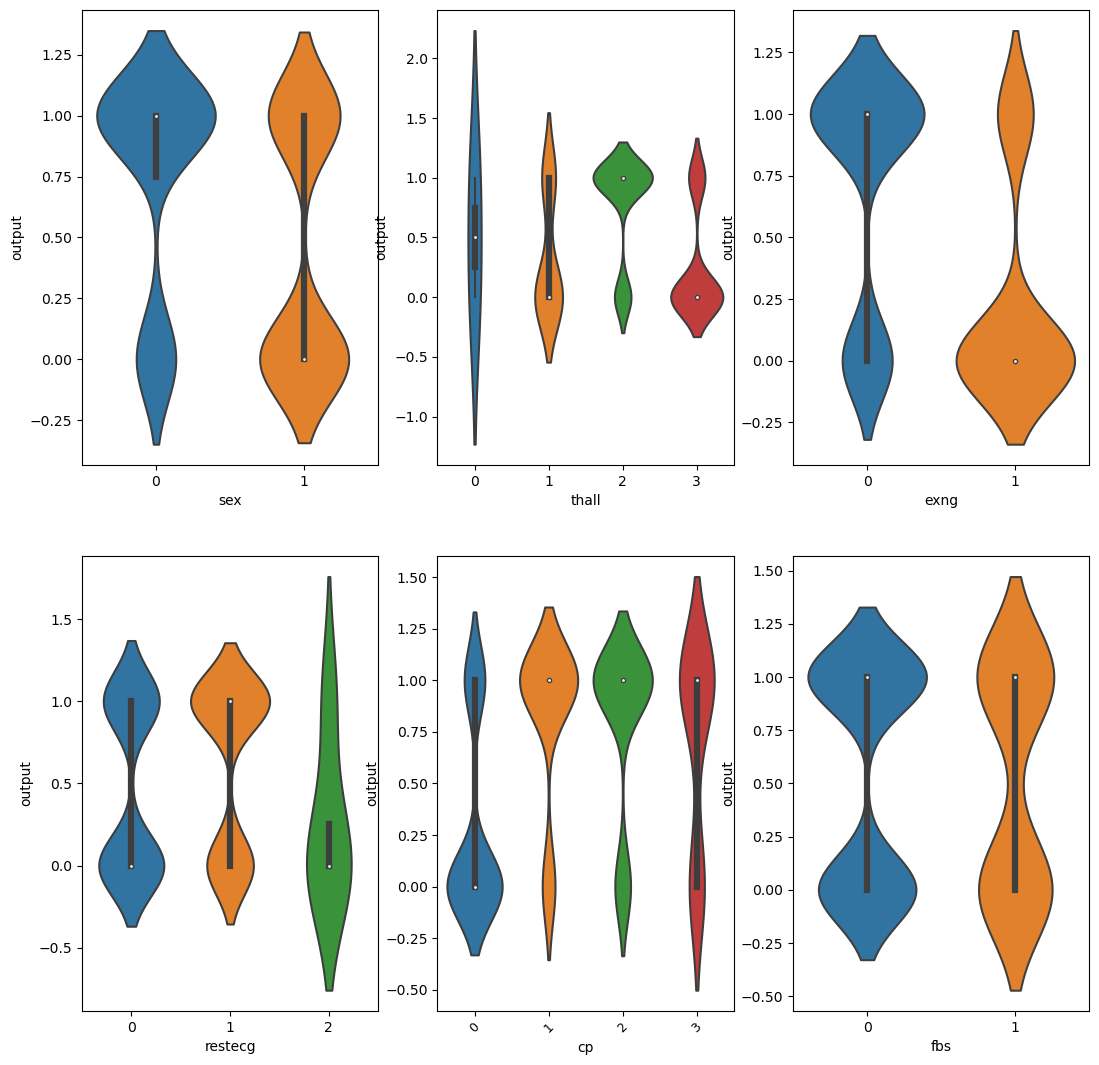

In [26]:
plt.figure(figsize=(13,13))
plt.subplot(2,3,1)
sns.violinplot(x = 'sex', y = 'output', data = heart)
plt.subplot(2,3,2)
sns.violinplot(x = 'thall', y = 'output', data = heart)
plt.subplot(2,3,3)
sns.violinplot(x = 'exng', y = 'output', data = heart)
plt.subplot(2,3,4)
sns.violinplot(x = 'restecg', y = 'output', data = heart)
plt.subplot(2,3,5)
sns.violinplot(x = 'cp', y = 'output', data = heart)
plt.xticks(fontsize=9, rotation=45)
plt.subplot(2,3,6)
sns.violinplot(x = 'fbs', y = 'output', data = heart)

plt.show()

# **Data preprocessing**

**There's no need for categorical encoding**

In [28]:
x = heart.iloc[:, 1:-1].values
y = heart.iloc[:, -1].values
x,y

(array([[  1.,   3., 145., ...,   0.,   0.,   1.],
        [  1.,   2., 130., ...,   0.,   0.,   2.],
        [  0.,   1., 130., ...,   2.,   0.,   2.],
        ...,
        [  1.,   0., 144., ...,   1.,   2.,   3.],
        [  1.,   0., 130., ...,   1.,   1.,   3.],
        [  0.,   1., 130., ...,   1.,   1.,   2.]]),
 array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0,

**Splitting the dataset into training and testing data**

In [29]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size= 0.3, random_state= 0)


In [30]:
print('Shape for training data', x_train.shape, y_train.shape)
print('Shape for testing data', x_test.shape, y_test.shape)

Shape for training data (211, 12) (211,)
Shape for testing data (91, 12) (91,)


**Feature Scaling**

In [31]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [32]:
x_train,x_test

(array([[ 0.73494625,  0.01364906, -0.19791836, ...,  0.9864245 ,
         -0.69321675, -0.46555391],
        [ 0.73494625,  1.9336168 ,  1.64024497, ..., -0.65243825,
          0.31553314, -0.46555391],
        [ 0.73494625, -0.94633481,  0.49139289, ..., -0.65243825,
          1.32428303,  1.14480471],
        ...,
        [ 0.73494625,  1.9336168 , -0.65745919, ..., -0.65243825,
         -0.69321675,  1.14480471],
        [ 0.73494625,  0.97363293,  0.37650768, ...,  0.9864245 ,
         -0.69321675, -0.46555391],
        [ 0.73494625,  0.97363293,  0.03185206, ...,  0.9864245 ,
          1.32428303,  1.14480471]]),
 array([[ 0.73494625,  0.01364906, -0.65745919, ..., -0.65243825,
          0.31553314,  1.14480471],
        [ 0.73494625,  1.9336168 ,  2.214671  , ..., -0.65243825,
         -0.69321675,  1.14480471],
        [ 0.73494625,  0.97363293, -0.37024617, ..., -0.65243825,
         -0.69321675,  1.14480471],
        ...,
        [ 0.73494625,  0.97363293, -0.37024617, ..., -

### 1.Linear

Training Accuracy: 84.36%
Testing Accuracy: 80.22%
Mean Squared Error (MSE): 0.15
Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.71      0.78        45
           1       0.76      0.89      0.82        46

    accuracy                           0.80        91
   macro avg       0.81      0.80      0.80        91
weighted avg       0.81      0.80      0.80        91



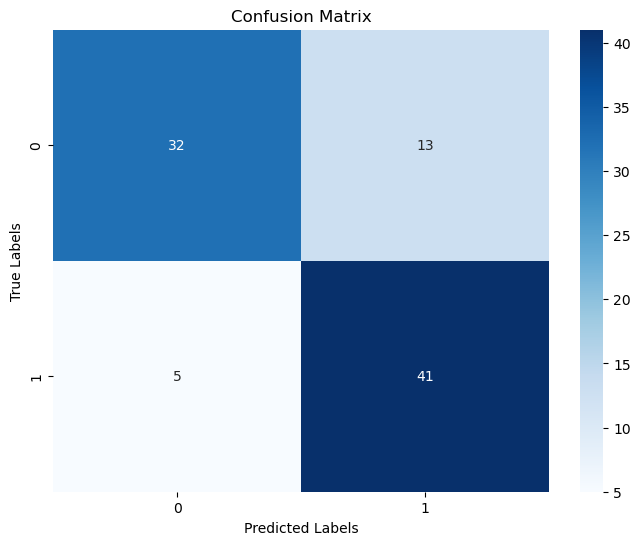

'plt.figure(figsize=(8, 6))\nplt.scatter(y_test, predicted)\nplt.title("True Values vs Predicted Values (Testing Data)")\nplt.xlabel("True Values")\nplt.ylabel("Predicted Values")\nplt.show()'

In [37]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import numpy as np

# Assuming x_train, y_train, x_test, y_test are your training and testing data

# Create a Linear Regression model
model = LinearRegression()

# Train the model
model.fit(x_train, y_train)

# Make predictions on training data
train_predictions = model.predict(x_train)

train_r2_score = r2_score(y_train, train_predictions)









# Make predictions on testing data
predicted = model.predict(x_test)
tpredicted=model.predict(x_train)
# Other metrics (not typical for regression, included for demonstration)
# Standardize the predictions for classification-like metrics
predicted_binary = (predicted > 0.5).astype(int)  # Assuming a binary classification threshold
train_predicted_binary = (tpredicted > 0.5).astype(int)
y_test_binary = (y_test > 0.5).astype(int)
y_train_binary = (y_train > 0.5).astype(int)

train_accuracy = accuracy_score(y_train_binary, train_predicted_binary)
print("Training Accuracy: {:.2f}%".format(train_accuracy * 100))

# Calculate and print accuracy (not typical for regression)
test_accuracy = accuracy_score(y_test_binary, predicted_binary)
print("Testing Accuracy: {:.2f}%".format(test_accuracy * 100))

# Calculate and print mean squared error (MSE) for regression
mse = mean_squared_error(y_test, predicted)
print("Mean Squared Error (MSE): {:.2f}".format(mse))

# Print classification report
class_report = classification_report(y_test_binary, predicted_binary)
print("Classification Report:")
print(class_report)

# Plot the confusion matrix as a heatmap
conf_matrix = confusion_matrix(y_test_binary, predicted_binary)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=np.unique(y_test_binary), yticklabels=np.unique(y_test_binary))
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

# Display a scatter plot of true values against predicted values for testing data
'''plt.figure(figsize=(8, 6))
plt.scatter(y_test, predicted)
plt.title("True Values vs Predicted Values (Testing Data)")
plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.show()'''


**2. Logistic Regression**

Training Accuracy: 85.31%
Testing Accuracy: 82.42%
Mean Squared Error (MSE): 0.18
Confusion Matrix:
[[34 11]
 [ 5 41]]
Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.76      0.81        45
           1       0.79      0.89      0.84        46

    accuracy                           0.82        91
   macro avg       0.83      0.82      0.82        91
weighted avg       0.83      0.82      0.82        91



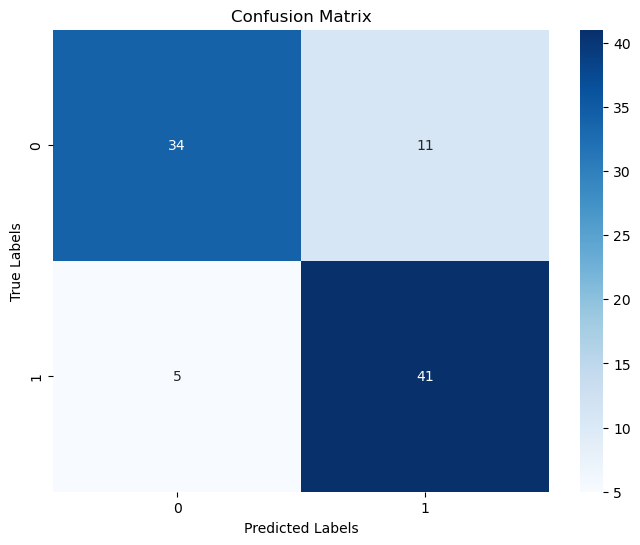

In [54]:

# Assuming x_train, y_train, x_test, y_test are your training and testing data

# Standardize the features
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# Create a Logistic Regression model with adjusted hyperparameters
model = LogisticRegression(C=0.002,solver='liblinear')  # You can adjust the value of C and other parameters

# Train the model
model.fit(x_train_scaled, y_train)

# Make predictions on training data
train_predictions = model.predict(x_train_scaled)

# Calculate and print training accuracy
train_accuracy = accuracy_score(y_train, train_predictions)
print("Training Accuracy: {:.2f}%".format(train_accuracy * 100))

# Make predictions on testing data
predicted = model.predict(x_test_scaled)

# Calculate and print testing accuracy
test_accuracy = accuracy_score(y_test, predicted)
print("Testing Accuracy: {:.2f}%".format(test_accuracy * 100))

# Calculate and print mean squared error (MSE) for regression (not typically used for classification)
mse = mean_squared_error(y_test, predicted)
print("Mean Squared Error (MSE): {:.2f}".format(mse))

# Create and print the confusion matrix
conf_matrix = confusion_matrix(y_test, predicted)
print("Confusion Matrix:")
print(conf_matrix)

# Print classification report
class_report = classification_report(y_test, predicted)
print("Classification Report:")
print(class_report)

# Plot the confusion matrix as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=model.classes_, yticklabels=model.classes_)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()


**2.Gaussian Naive Bayes**

Training Accuracy: 84.36%
Testing Accuracy: 82.42%

Confusion Matrix:
[[34 11]
 [ 5 41]]

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.76      0.81        45
           1       0.79      0.89      0.84        46

    accuracy                           0.82        91
   macro avg       0.83      0.82      0.82        91
weighted avg       0.83      0.82      0.82        91



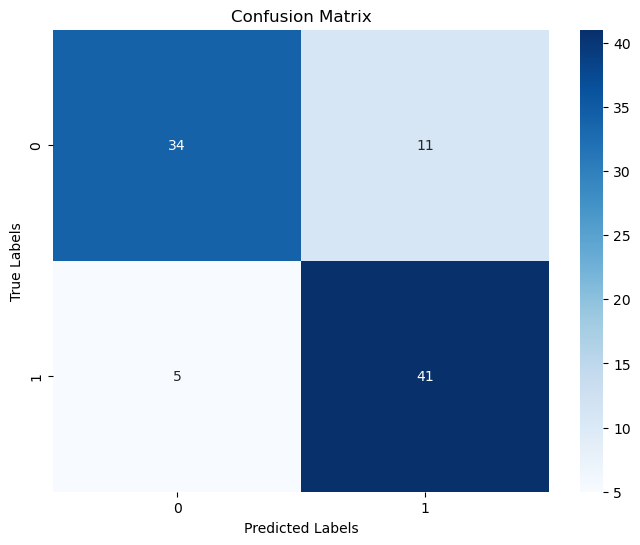

In [50]:
# Create a Gaussian Naive Bayes classifier
model = GaussianNB()

# Train the model
model.fit(x_train, y_train)

# Make predictions on training data
train_predictions = model.predict(x_train)

# Calculate and print training accuracy
train_accuracy = accuracy_score(y_train, train_predictions)
print("Training Accuracy: {:.2f}%".format(train_accuracy * 100))

# Make predictions on testing data
predicted = model.predict(x_test)

# Calculate and print accuracy
accuracy = accuracy_score(y_test, predicted)
print("Testing Accuracy: {:.2f}%".format(accuracy * 100))

# Create and print the confusion matrix as a heatmap
conf_matrix = confusion_matrix(y_test, predicted)
print("\nConfusion Matrix:")
print(conf_matrix)

# Print classification report
class_report = classification_report(y_test, predicted)
print("\nClassification Report:")
print(class_report)

# Plot the confusion matrix as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=model.classes_, yticklabels=model.classes_)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()


**4.Support Vector Machine**

Training Accuracy: 91.94%
Testing Accuracy: 83.52%
Confusion Matrix (Testing Data):
[[34 11]
 [ 4 42]]


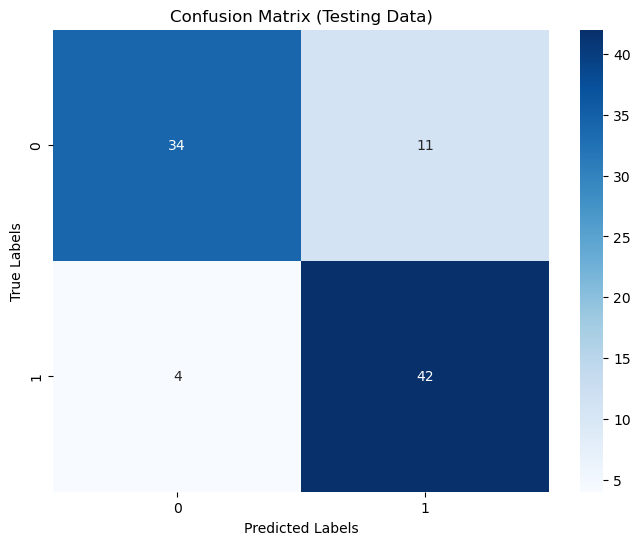

Confusion Matrix (Training Data):
[[ 84   9]
 [  8 110]]


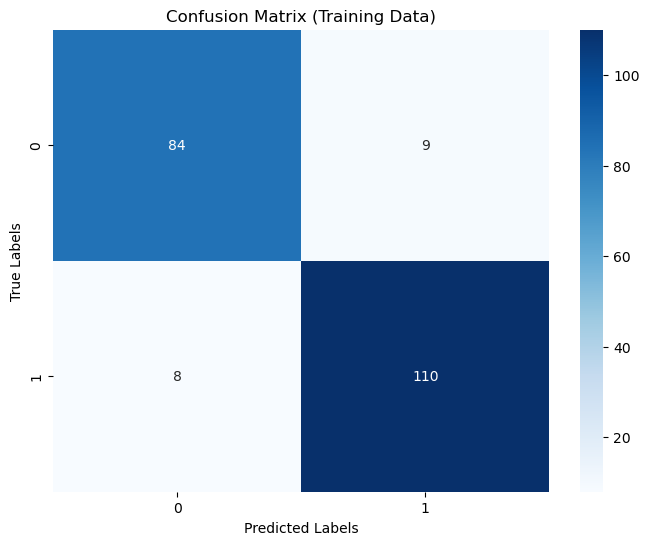

In [53]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming x_train, y_train, x_test, y_test are your training and testing data

# Create a Support Vector Machine classifier
model = SVC()

# Train the model
model.fit(x_train, y_train)

# Make predictions on training data
train_predictions = model.predict(x_train)

# Calculate and print training accuracy
train_accuracy = accuracy_score(y_train, train_predictions)
print("Training Accuracy: {:.2f}%".format(train_accuracy * 100))

# Make predictions on testing data
predicted = model.predict(x_test)

# Calculate and print testing accuracy
test_accuracy = accuracy_score(y_test, predicted)
print("Testing Accuracy: {:.2f}%".format(test_accuracy * 100))

# Create and print the confusion matrix for testing data
conf_matrix_test = confusion_matrix(y_test, predicted)
print("Confusion Matrix (Testing Data):")
print(conf_matrix_test)

# Plot the confusion matrix for testing data as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_test, annot=True, fmt="d", cmap="Blues", xticklabels=model.classes_, yticklabels=model.classes_)
plt.title("Confusion Matrix (Testing Data)")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

# Create and print the confusion matrix for training data
conf_matrix_train = confusion_matrix(y_train, train_predictions)
print("Confusion Matrix (Training Data):")
print(conf_matrix_train)

# Plot the confusion matrix for training data as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_train, annot=True, fmt="d", cmap="Blues", xticklabels=model.classes_, yticklabels=model.classes_)
plt.title("Confusion Matrix (Training Data)")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()


# Decision Tree

Training Accuracy: 93.84%
Testing Accuracy: 78.02%
Mean Squared Error (MSE): 0.22
Confusion Matrix:
[[34 11]
 [ 9 37]]
Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.76      0.77        45
           1       0.77      0.80      0.79        46

    accuracy                           0.78        91
   macro avg       0.78      0.78      0.78        91
weighted avg       0.78      0.78      0.78        91



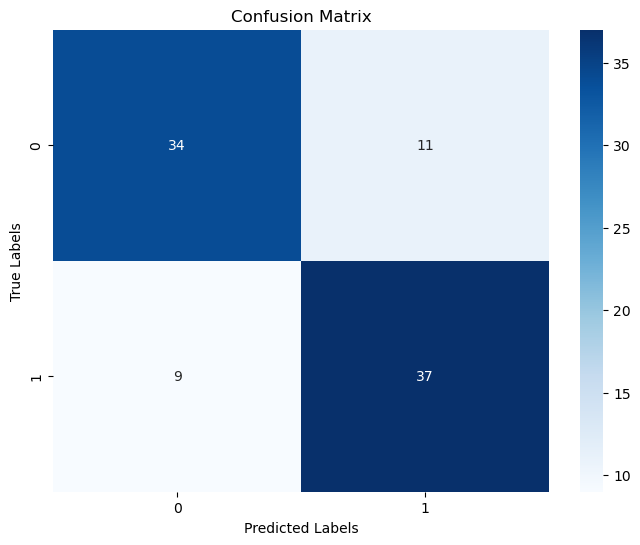

In [38]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, mean_squared_error, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming x_train, y_train, x_test, y_test are your training and testing data

# Create a Decision Tree Classifier
model = DecisionTreeClassifier(max_depth=5, random_state=0)  # Increase max_depth or adjust other hyperparameters

# Train the model
model.fit(x_train, y_train)

# Make predictions on training data
train_predictions = model.predict(x_train)

# Calculate and print training accuracy
train_accuracy = accuracy_score(y_train, train_predictions)
print("Training Accuracy: {:.2f}%".format(train_accuracy * 100))

# Make predictions on testing data
predicted = model.predict(x_test)

# Calculate and print testing accuracy
test_accuracy = accuracy_score(y_test, predicted)
print("Testing Accuracy: {:.2f}%".format(test_accuracy * 100))

# Calculate and print mean squared error (MSE) for regression
mse = mean_squared_error(y_test, predicted)
print("Mean Squared Error (MSE): {:.2f}".format(mse))

# Create and print the confusion matrix
conf_matrix = confusion_matrix(y_test, predicted)
print("Confusion Matrix:")
print(conf_matrix)

# Print classification report
class_report = classification_report(y_test, predicted)
print("Classification Report:")
print(class_report)

# Plot the confusion matrix as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=model.classes_, yticklabels=model.classes_)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()


**5.Random Forest**

The accuracy of Random Forest is: 82.42%
Training Accuracy: 96.68%
Testing Accuracy: 82.42%
Confusion Matrix (Testing Data):
[[36  9]
 [ 7 39]]


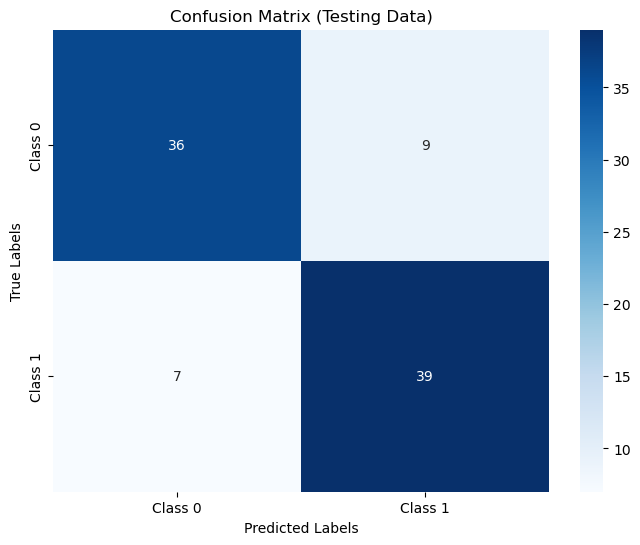

Confusion Matrix (Training Data):
[[ 86   7]
 [  0 118]]


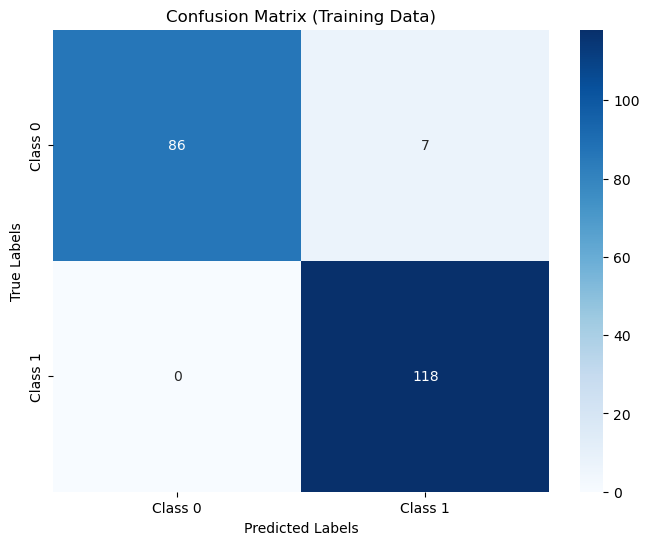

Confusion Matrix:
[[36  9]
 [ 7 39]]


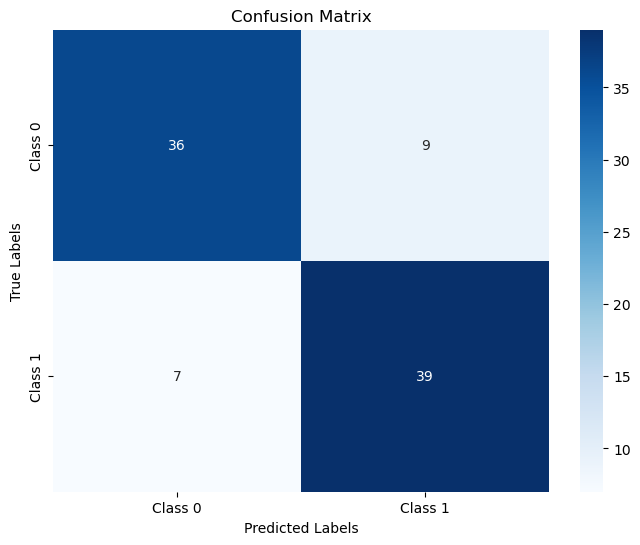

In [39]:


# Assuming x_train, y_train, x_test, y_test are your training and testing data

# Create a RandomForestRegressor (Note: Typically used for regression, consider using RandomForestClassifier for classification)
model = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=0)

# Train the model
model.fit(x_train, y_train)

# Make predictions
predicted = model.predict(x_test)

# Convert predictions to binary classes for classification
predicted_classes = [1 if pred > 0.5 else 0 for pred in predicted]

# Calculate and print accuracy
accuracy = accuracy_score(y_test, predicted_classes)
print("The accuracy of Random Forest is: {:.2f}%".format(accuracy * 100))

# Create and print the confusion matrix as a heatmapfrom sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming x_train, y_train, x_test, y_test are your training and testing data

# Create a RandomForestRegressor (Note: Typically used for regression, consider using RandomForestClassifier for classification)
model = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=0)

# Train the model
model.fit(x_train, y_train)

# Make predictions on training data
train_predictions = model.predict(x_train)

# Convert predictions to binary classes for classification
train_predicted_classes = [1 if pred > 0.5 else 0 for pred in train_predictions]

# Calculate and print training accuracy
train_accuracy = accuracy_score(y_train, train_predicted_classes)
print("Training Accuracy: {:.2f}%".format(train_accuracy * 100))

# Make predictions on testing data
predicted = model.predict(x_test)

# Convert predictions to binary classes for classification
predicted_classes = [1 if pred > 0.5 else 0 for pred in predicted]

# Calculate and print testing accuracy
test_accuracy = accuracy_score(y_test, predicted_classes)
print("Testing Accuracy: {:.2f}%".format(test_accuracy * 100))

# Create and print the confusion matrix for testing data
conf_matrix_test = confusion_matrix(y_test, predicted_classes)
print("Confusion Matrix (Testing Data):")
print(conf_matrix_test)

# Plot the confusion matrix for testing data as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_test, annot=True, fmt="d", cmap="Blues", xticklabels=["Class 0", "Class 1"], yticklabels=["Class 0", "Class 1"])
plt.title("Confusion Matrix (Testing Data)")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

# Create and print the confusion matrix for training data
conf_matrix_train = confusion_matrix(y_train, train_predicted_classes)
print("Confusion Matrix (Training Data):")
print(conf_matrix_train)

# Plot the confusion matrix for training data as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_train, annot=True, fmt="d", cmap="Blues", xticklabels=["Class 0", "Class 1"], yticklabels=["Class 0", "Class 1"])
plt.title("Confusion Matrix (Training Data)")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

conf_matrix = confusion_matrix(y_test, predicted_classes)
print("Confusion Matrix:")
print(conf_matrix)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=["Class 0", "Class 1"], yticklabels=["Class 0", "Class 1"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()


**6.Optimised K Nearest Neighbours**

Confusion Matrix (Training Data):
[[ 76  17]
 [ 10 108]]
Training Accuracy: 87.20%
Mean Squared Error (MSE) - Training: 0.13
Classification Report - Training Data:
              precision    recall  f1-score   support

           0       0.88      0.82      0.85        93
           1       0.86      0.92      0.89       118

    accuracy                           0.87       211
   macro avg       0.87      0.87      0.87       211
weighted avg       0.87      0.87      0.87       211


Confusion Matrix (Testing Data):
[[33 12]
 [ 5 41]]
Testing Accuracy: 81.32%
Mean Squared Error (MSE) - Testing: 0.19
Classification Report - Testing Data:
              precision    recall  f1-score   support

           0       0.87      0.73      0.80        45
           1       0.77      0.89      0.83        46

    accuracy                           0.81        91
   macro avg       0.82      0.81      0.81        91
weighted avg       0.82      0.81      0.81        91



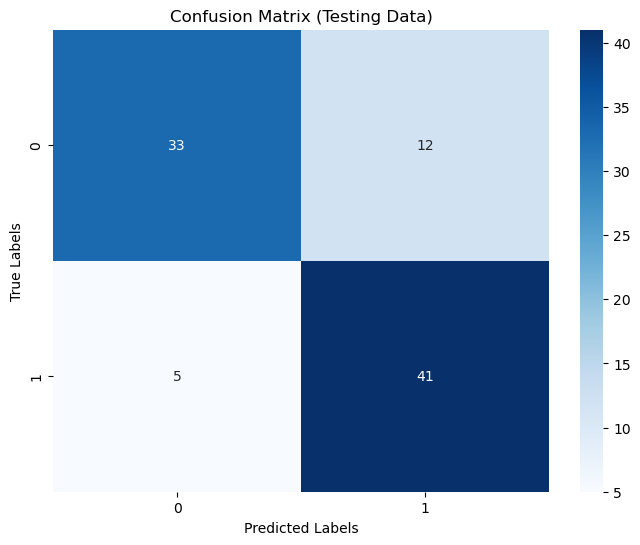

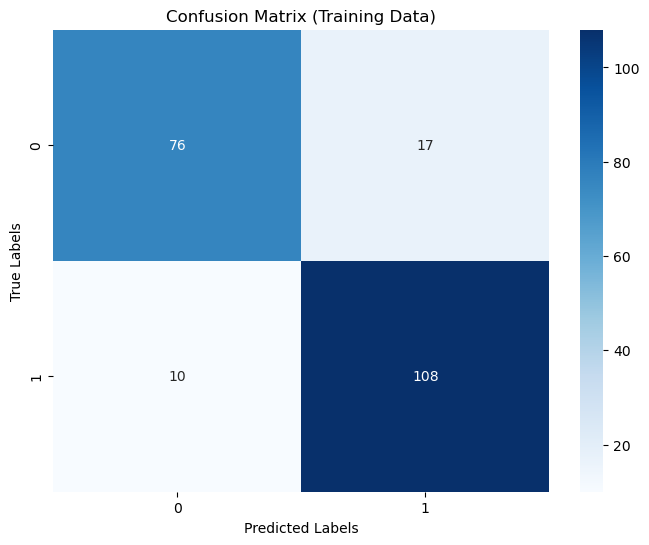

In [48]:


# Assuming x_train, y_train, x_test, y_test are your training and testing data

# Create a KNeighborsClassifier
model = KNeighborsClassifier(n_neighbors=5)

# Train the model
model.fit(x_train, y_train)

# Make predictions on training data
train_predictions = model.predict(x_train)

# Create and print the confusion matrix for training data
conf_matrix_train = confusion_matrix(y_train, train_predictions)
print("Confusion Matrix (Training Data):")
print(conf_matrix_train)

# Calculate and print training accuracy
train_accuracy = accuracy_score(y_train, train_predictions)
print("Training Accuracy: {:.2f}%".format(train_accuracy * 100))

# Calculate and print mean squared error (MSE) for regression (not typically used for classification)
mse_train = mean_squared_error(y_train, train_predictions)
print("Mean Squared Error (MSE) - Training: {:.2f}".format(mse_train))

# Print classification report for training data
class_report_train = classification_report(y_train, train_predictions)
print("Classification Report - Training Data:")
print(class_report_train)

# Make predictions on testing data
predicted = model.predict(x_test)

# Create and print the confusion matrix for testing data
conf_matrix_test = confusion_matrix(y_test, predicted)
print("\nConfusion Matrix (Testing Data):")
print(conf_matrix_test)

# Print testing accuracy
test_accuracy = accuracy_score(y_test, predicted)
print("Testing Accuracy: {:.2f}%".format(test_accuracy * 100))

# Calculate and print mean squared error (MSE) for regression (not typically used for classification)
mse_test = mean_squared_error(y_test, predicted)
print("Mean Squared Error (MSE) - Testing: {:.2f}".format(mse_test))

# Print classification report for testing data
class_report_test = classification_report(y_test, predicted)
print("Classification Report - Testing Data:")
print(class_report_test)

# Plot the confusion matrix for testing data as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_test, annot=True, fmt="d", cmap="Blues", xticklabels=model.classes_, yticklabels=model.classes_)
plt.title("Confusion Matrix (Testing Data)")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

# Plot the confusion matrix for training data as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_train, annot=True, fmt="d", cmap="Blues", xticklabels=model.classes_, yticklabels=model.classes_)
plt.title("Confusion Matrix (Training Data)")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()


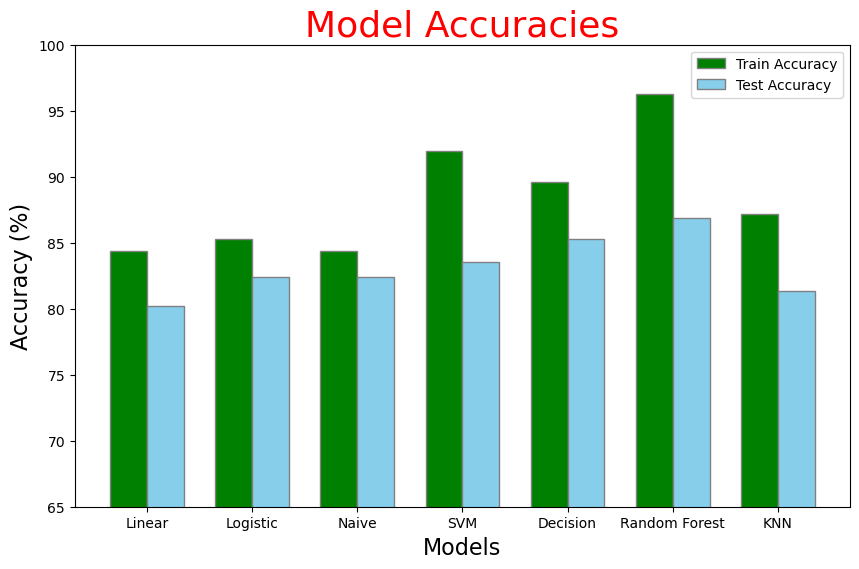

In [38]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 6))

models = ['Linear','Logistic', 'Naive','SVM', 'Decision', 'Random Forest','KNN']
bar_width = 0.35  # width of the bars

test_accuracies = [80.22, 82.42, 82.42,83.52, 85.25, 86.89,81.32]
train_accuracies = [84.36, 85.31, 84.36, 91.94, 89.63, 96.27,87.20]

# Set positions for the bars
r1 = np.arange(len(models))
r2 = [x + bar_width for x in r1]

# Create the bar plots
plt.bar(r1, train_accuracies, color='green', width=bar_width, edgecolor='grey', label='Train Accuracy')
plt.bar(r2, test_accuracies, color='skyblue', width=bar_width, edgecolor='grey', label='Test Accuracy')

# Set labels and title
plt.xlabel('Models', fontsize=16)
plt.ylabel('Accuracy (%)', fontsize=16)
plt.title('Model Accuracies', fontsize=26,color='red')

# Set x-axis ticks and labels
plt.xticks([r + bar_width/2 for r in range(len(models))], models)

# Set y-axis range
plt.ylim(65, 100)

# Add legend
plt.legend()

# Show the plot
plt.show()

 # **Conclusion**

1. Most of the models are performing really well.
2. SVM is performing the best for the given dataset.